In [1]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
import os
from dotenv import load_dotenv

load_dotenv()

url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"), 
    host=os.getenv("DB_HOST"),
    port=int(os.getenv("DB_PORT")),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(url)

with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
query = """
SELECT *
FROM features.product_features
"""

product_df = pd.read_sql(query, engine)

product_df.shape

(49677, 12)

In [5]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49677 entries, 0 to 49676
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         49677 non-null  int64  
 1   product_name       49677 non-null  object 
 2   department         49677 non-null  object 
 3   aisle              49677 non-null  object 
 4   purchase_count     49677 non-null  int64  
 5   unique_customers   49677 non-null  int64  
 6   unique_orders      49677 non-null  int64  
 7   reorder_rate       49677 non-null  float64
 8   total_reorders     49677 non-null  int64  
 9   avg_cart_position  49677 non-null  float64
 10  std_cart_position  49546 non-null  float64
 11  avg_purchase_hour  49677 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 4.5+ MB


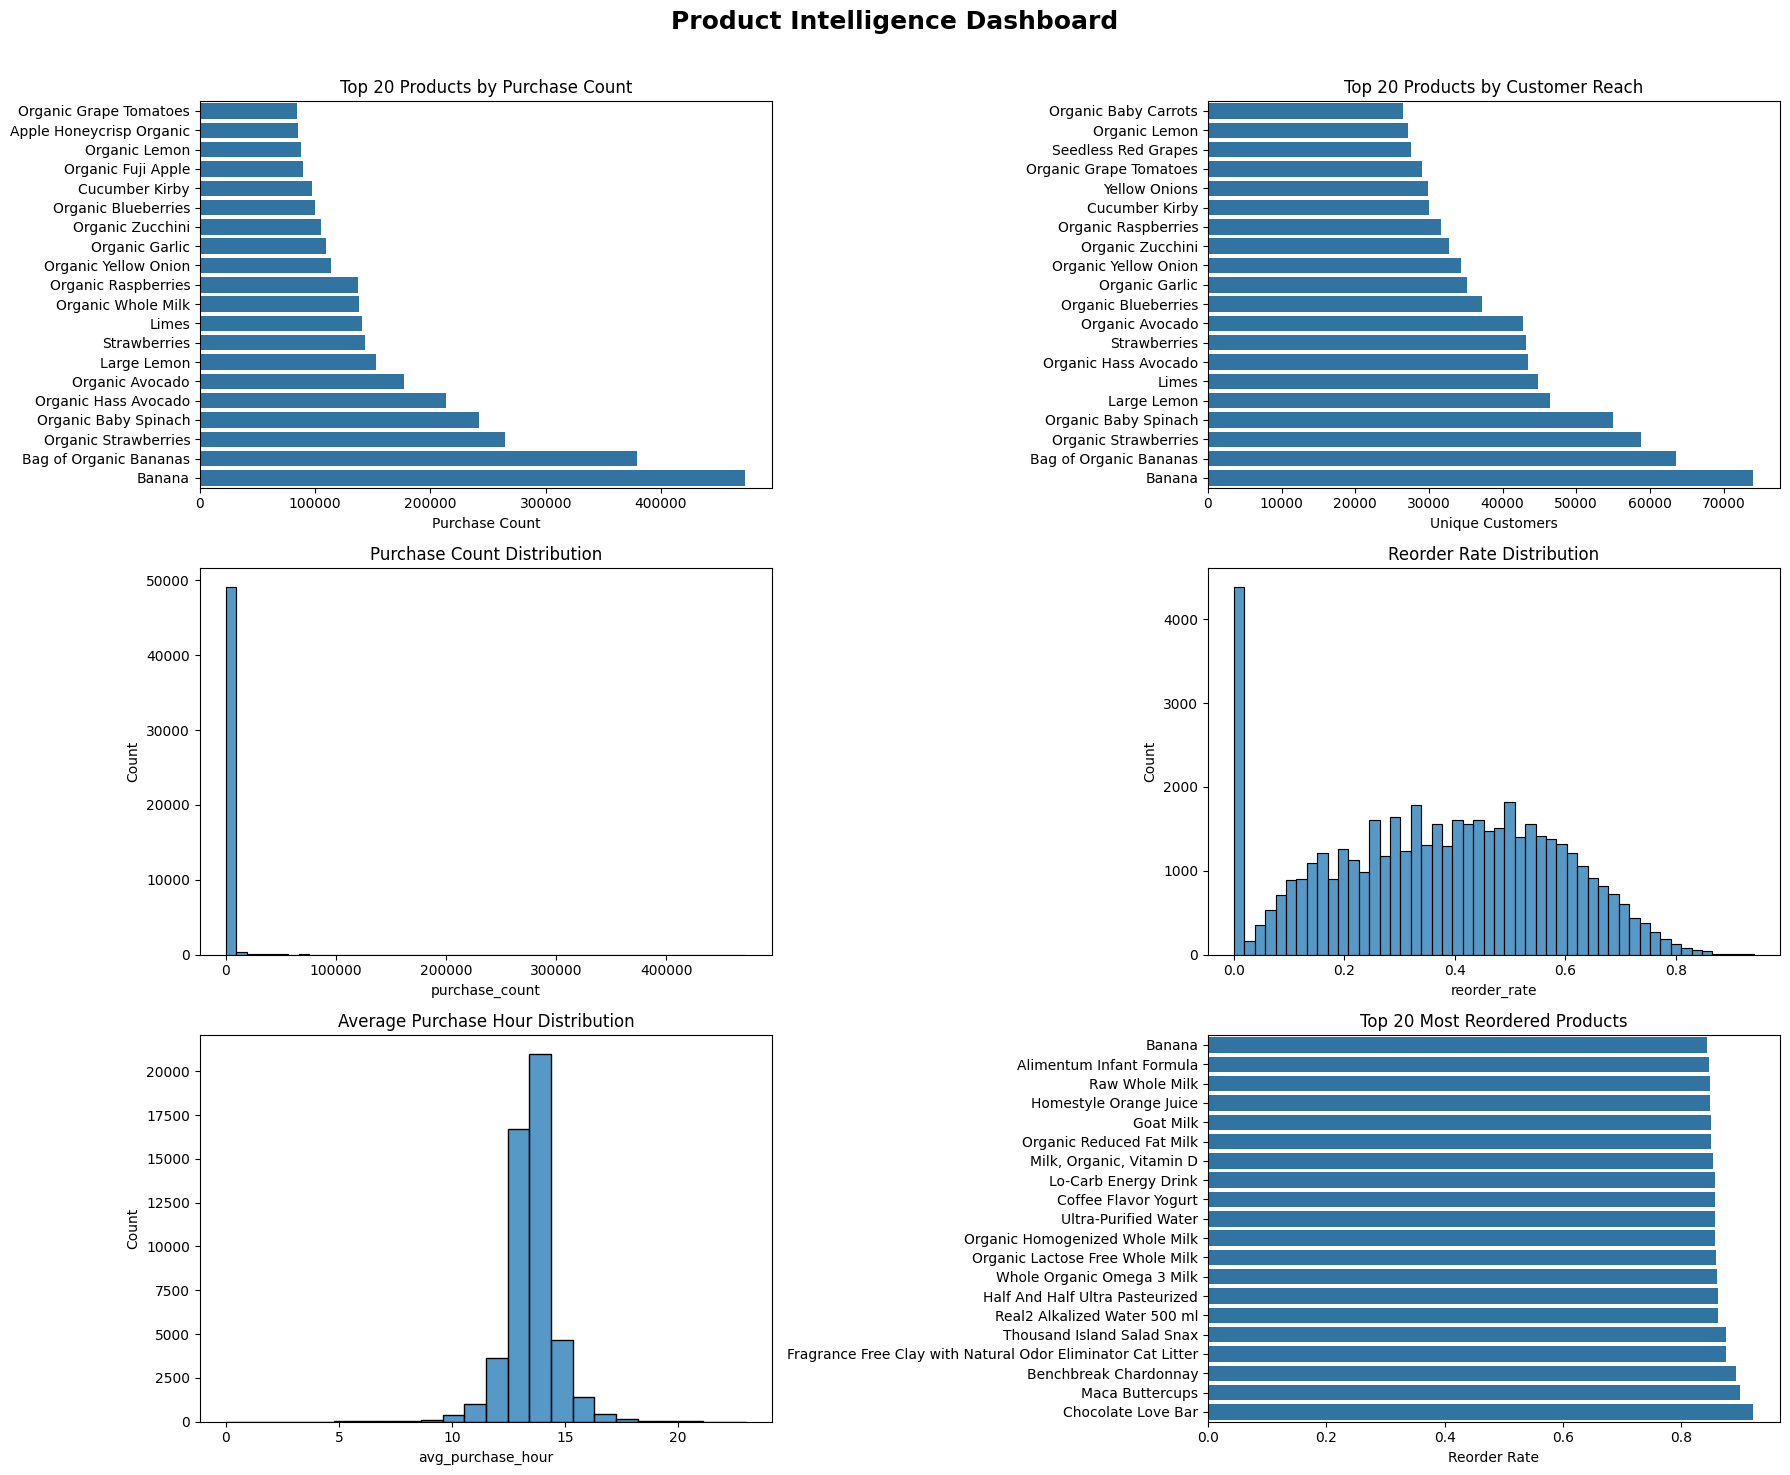

In [ ]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 15)
)

axes = axes.flatten()

# ---------------------------------------
# 1. Top Products by Purchase Count
# ---------------------------------------

top_products = (
    product_df
    .nlargest(20, "purchase_count")
    .sort_values("purchase_count", ascending=True)
)

sns.barplot(
    data=top_products,
    x="purchase_count",
    y="product_name",
    ax=axes[0]
)

axes[0].set_title("Top 20 Products by Purchase Count")
axes[0].set_xlabel("Purchase Count")
axes[0].set_ylabel("")

# ---------------------------------------
# 2. Top Products by Unique Customers
# ---------------------------------------

top_customers = (
    product_df
    .nlargest(20, "unique_customers")
    .sort_values("unique_customers", ascending=True)
)

sns.barplot(
    data=top_customers,
    x="unique_customers",
    y="product_name",
    ax=axes[1]
)

axes[1].set_title("Top 20 Products by Customer Reach")
axes[1].set_xlabel("Unique Customers")
axes[1].set_ylabel("")

# ---------------------------------------
# 3. Purchase Count Distribution
# ---------------------------------------

sns.histplot(
    product_df["purchase_count"],
    bins=50,
    ax=axes[2]
)

axes[2].set_title("Purchase Count Distribution")

# ---------------------------------------
# 4. Reorder Rate Distribution
# ---------------------------------------

sns.histplot(
    product_df["reorder_rate"],
    bins=50,
    ax=axes[3]
)

axes[3].set_title("Reorder Rate Distribution")

# ---------------------------------------
# 5. Average Purchase Hour Distribution
# ---------------------------------------

sns.histplot(
    product_df["avg_purchase_hour"],
    bins=24,
    ax=axes[4]
)

axes[4].set_title("Average Purchase Hour Distribution")

# ---------------------------------------
# 6. Top Products by Reorder Rate
# (minimum purchase threshold)
# ---------------------------------------

reorder_leaders = (
    product_df[product_df["purchase_count"] >= 100]
    .nlargest(20, "reorder_rate")
    .sort_values("reorder_rate", ascending=True)
)

sns.barplot(
    data=reorder_leaders,
    x="reorder_rate",
    y="product_name",
    ax=axes[5]
)

axes[5].set_title("Top 20 Most Reordered Products")
axes[5].set_xlabel("Reorder Rate")
axes[5].set_ylabel("")

# ---------------------------------------
# Layout
# ---------------------------------------

plt.suptitle(
    "Product Intelligence Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

# Product Intelligence Analysis

The Product Intelligence Dashboard provides insights into product popularity, customer reach, reorder behavior, and purchasing patterns across 49,677 products.

---

## 1. Top Products by Purchase Count

The most frequently purchased products are dominated by fresh produce and grocery staples.

### Top Products

- Banana
- Bag of Organic Bananas
- Organic Strawberries
- Organic Baby Spinach
- Organic Hass Avocado

### Key Insights

- Fresh fruits and vegetables dominate overall purchase volume.
- Organic products appear prominently among the most purchased items.
- A relatively small set of products drives a large portion of total transactions.

### Business Implications

- High-volume products require careful inventory management.
- Stockouts for these products would significantly impact customer experience.
- These products can serve as anchor items for recommendation systems.

---

## 2. Top Products by Customer Reach

Customer reach measures the number of unique customers purchasing a product.

### Key Insights

- Bananas have the largest customer reach.
- Organic produce dominates the highest-reach products.
- Popular products tend to appeal to a broad customer base rather than niche segments.

### Business Implications

- These products represent "gateway products" that attract and retain customers.
- Broadly purchased products provide excellent opportunities for cross-selling and bundle recommendations.

---

## 3. Purchase Count Distribution

The purchase count distribution exhibits an extreme long-tail pattern.

### Key Insights

- Most products are purchased relatively infrequently.
- A small number of products account for a disproportionately large share of purchases.
- Product popularity follows a power-law distribution commonly observed in retail and e-commerce.

### Business Implications

- Inventory optimization should prioritize high-volume products.
- Recommendation systems should balance popular products with long-tail discovery.
- Long-tail products contribute significantly to catalog diversity.

---

## 4. Reorder Rate Distribution

Reorder rates are distributed across a wide range of values.

### Key Insights

- Most products have moderate reorder rates.
- A significant number of products exhibit high repeat-purchase behavior.
- Some products are rarely reordered and are likely purchased occasionally or seasonally.

### Business Implications

- Reorder rate serves as a strong indicator of product stickiness.
- High-reorder products contribute heavily to customer retention.
- Products with low reorder rates may require different recommendation strategies.

---

## 5. Average Purchase Hour Distribution

Average purchase hours are concentrated within a narrow range.

### Key Insights

- Most products are purchased during daytime hours.
- Product purchasing behavior closely follows overall customer shopping activity.
- No major product groups appear to be associated with late-night purchasing.

### Business Implications

- Product demand aligns strongly with customer activity patterns.
- Marketing and promotional activities can be synchronized with peak purchasing hours.

---

## 6. Top Most Reordered Products

The highest reorder-rate products are dominated by staple grocery and household items.

### Examples

- Banana
- Milk Products
- Infant Formula
- Water Products
- Household Essentials

### Key Insights

- Frequently reordered products are primarily consumable goods.
- Customers repeatedly purchase these products as part of regular shopping routines.
- These products demonstrate exceptionally strong customer loyalty.

### Business Implications

- High-reorder products are ideal candidates for replenishment recommendations.
- Subscription and recurring-order services would be particularly effective for these products.
- Demand forecasting for these products is likely to be highly reliable.

---

# Overall Findings

The product catalog exhibits a classic e-commerce structure:

### Head Products

A small number of products generate extremely high purchase volumes and customer reach.

Examples include:

- Banana
- Bag of Organic Bananas
- Organic Strawberries
- Organic Baby Spinach

These products form the core of customer shopping baskets.

---

### Long-Tail Products

The majority of products are purchased relatively infrequently.

Although individually low-volume, these products collectively contribute to customer choice and catalog diversity.

---

### High-Loyalty Products

Products with high reorder rates demonstrate strong customer dependence and recurring demand.

These products represent the most valuable opportunities for:

- Personalized recommendations
- Subscription services
- Replenishment reminders
- Inventory planning

---

# Conclusion

The Product Intelligence analysis reveals that customer purchasing behavior is concentrated around a relatively small set of highly popular and highly reordered products, while the majority of products form a long-tail catalog. Fresh produce and grocery staples dominate both purchase volume and customer reach, highlighting their importance in customer retention and overall platform engagement.

These findings provide a strong foundation for product intelligence services, recommendation systems, demand forecasting, inventory optimization, and future GenAI-powered business insights within the CommerceAI platform.